
  Bracketing from x0 = 0.0,  initial delta = 1.0

  Point                     x           f(x)  Action
  ──────────────────────────────────────────────────────────────
  xa                 0.000000       0.000000  starting point
  xb                 1.000000     -23.000000  first step
  xc (iter 1)        3.000000      33.000000  delta doubled to 2.00000

  Straddle confirmed: f(xc) >= f(xb).
  Minimum lies between xa = 0.0000 and xc = 3.0000.

  x_(k+1)            2.000000       4.000000  fourth point: xb + delta/2 = 1.0000 + 1.0000

  Best three points retained (sorted by x):
  ──────────────────────────────────────────────────────────────
  x1                 0.000000       0.000000
  x2                 1.000000     -23.000000  <- lowest f
  x3                 2.000000       4.000000
  ──────────────────────────────────────────────────────────────
  Straddle check:  f(x1) >= f(x2): True,  f(x3) >= f(x2): True

  Quadratic Refinement
  ───────────────────────────────────────────────

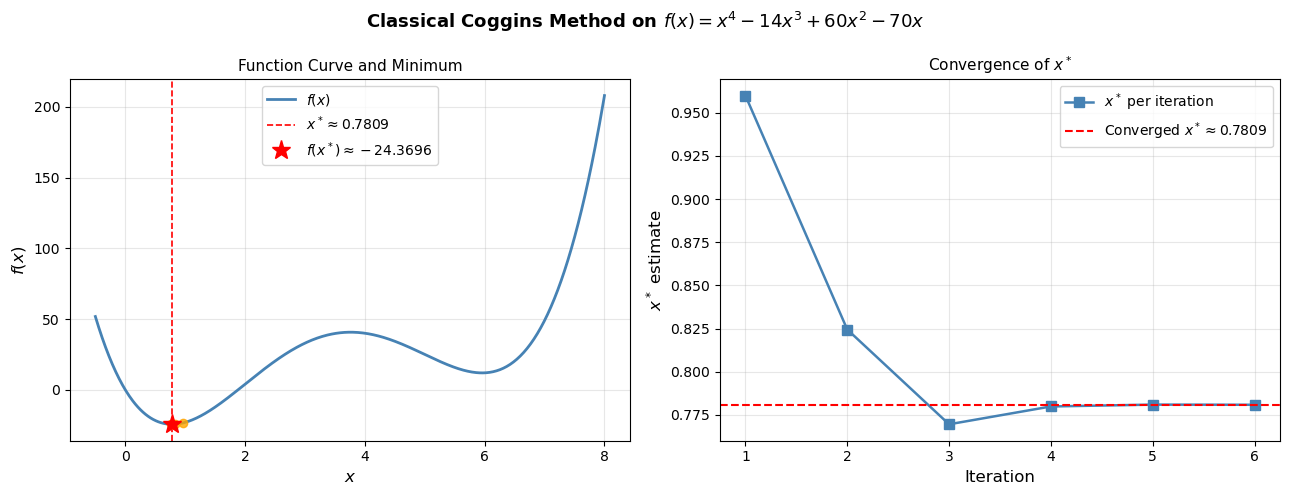

Plot saved as coggins_quartic.png

  Bracketing from x0 = 0.0,  initial delta = 1.0

  Point                     x           f(x)  Action
  ──────────────────────────────────────────────────────────────
  xa                 0.000000       0.000000  starting point
  xb                 1.000000     -23.000000  first step
  xc (iter 1)        3.000000      33.000000  delta doubled to 2.00000

  Straddle confirmed: f(xc) >= f(xb).
  Minimum lies between xa = 0.0000 and xc = 3.0000.

  x_(k+1)            2.000000       4.000000  fourth point: xb + delta/2 = 1.0000 + 1.0000

  Best three points retained (sorted by x):
  ──────────────────────────────────────────────────────────────
  x1                 0.000000       0.000000
  x2                 1.000000     -23.000000  <- lowest f
  x3                 2.000000       4.000000
  ──────────────────────────────────────────────────────────────
  Straddle check:  f(x1) >= f(x2): True,  f(x3) >= f(x2): True

Bracketing output saved to bracketing_

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════
#  OBJECTIVE FUNCTION
#  f(x) = x^4 - 14x^3 + 60x^2 - 70x
# ══════════════════════════════════════════════════════════════════════

def f(x):
    return x**4 - 14*x**3 + 60*x**2 - 70*x


# ══════════════════════════════════════════════════════════════════════
#  STAGE 1: BRACKETING PHASE
#
#  1. Start at xa = x0, evaluate f(xa).
#  2. Step to xb = xa + delta, evaluate f(xb).
#  3. If f(xb) >= f(xa): no improvement — REVERSE direction.
#  4. Doubling loop:
#       a. Double delta
#       b. Step to xc = xb + delta, evaluate f(xc)
#       c. If f(xc) >= f(xb): straddle confirmed — STOP
#       d. If f(xc) <  f(xb): shift window forward and repeat
#  5. Locate x_(k+1) = xb + delta/2   <-- corrected formula
#  6. Pool all four points, retain best three that straddle optimum.
# ══════════════════════════════════════════════════════════════════════

def bracket_minimum(func, x0, delta=1.0):

    # ── Point A: starting point ───────────────────────────────────────
    xa = x0
    fa = func(xa)

    # ── Point B: one step from starting point ─────────────────────────
    xb = xa + delta
    fb = func(xb)

    print(f"\n  Bracketing from x0 = {x0},  initial delta = {delta}")
    print(f"\n  {'Point':<16} {'x':>10} {'f(x)':>14}  Action")
    print(f"  {'─'*62}")
    print(f"  {'xa':<16} {xa:>10.6f} {fa:>14.6f}  starting point")
    print(f"  {'xb':<16} {xb:>10.6f} {fb:>14.6f}  first step")

    # ── Direction reversal if no improvement ─────────────────────────
    if fb >= fa:
        delta = -delta
        xb = xa + delta
        fb = func(xb)
        print(f"  {'xb (reversed)':<16} {xb:>10.6f} {fb:>14.6f}"
              f"  no improvement — reversed direction")

    # ── Doubling loop: keep going until minimum is straddled ──────────
    iteration = 0
    while True:
        iteration += 1
        delta *= 2.0
        xc = xb + delta
        fc = func(xc)

        print(f"  {'xc (iter '+str(iteration)+')':<16} {xc:>10.6f} "
              f"{fc:>14.6f}  delta doubled to {delta:.5f}")

        if fc >= fb:
            # f(xc) worse than f(xb) — minimum is straddled
            print(f"\n  Straddle confirmed: f(xc) >= f(xb).")
            print(f"  Minimum lies between xa = {xa:.4f} "
                  f"and xc = {xc:.4f}.")
            break

        # Still descending — shift window forward
        xa, fa = xb, fb
        xb, fb = xc, fc

    # ── Locate x_(k+1) = xb + delta/2 ────────────────────────────────
    # after the straddle is confirmed,
    # the fourth point is placed at xb + delta/2, NOT xb + delta.
    # This places it inside the confirmed bracket, tightening the
    # interval before the quadratic fit begins.
    x_k1 = xb + delta / 2.0
    f_k1 = func(x_k1)

    print(f"\n  {'x_(k+1)':<16} {x_k1:>10.6f} {f_k1:>14.6f}"
          f"  fourth point: xb + delta/2 = "
          f"{xb:.4f} + {delta/2:.4f}")

    # ── Pool all four, retain best three ─────────────────────────────
    all_four = [(xa, fa), (xb, fb), (xc, fc), (x_k1, f_k1)]
    all_four.sort(key=lambda p: p[1])           # sort by f, best first
    best3 = sorted(all_four[:3], key=lambda p: p[0])  # sort by x

    x1, f1 = best3[0]
    x2, f2 = best3[1]
    x3, f3 = best3[2]

    print(f"\n  Best three points retained (sorted by x):")
    print(f"  {'─'*62}")
    print(f"  {'x1':<16} {x1:>10.6f} {f1:>14.6f}")
    print(f"  {'x2':<16} {x2:>10.6f} {f2:>14.6f}  <- lowest f")
    print(f"  {'x3':<16} {x3:>10.6f} {f3:>14.6f}")
    print(f"  {'─'*62}")
    print(f"  Straddle check:  f(x1) >= f(x2): {f1 >= f2},  "
          f"f(x3) >= f(x2): {f3 >= f2}")

    return x1, x2, x3, f1, f2, f3


# ══════════════════════════════════════════════════════════════════════
#  STAGE 2: QUADRATIC INTERPOLATION FORMULA
#
#  With x1, x2, x3 straddling the optimum, fit a quadratic and
#  find its minimum x* by setting df/dx = 0:
#
#       (x2^2 - x3^2)f1 + (x3^2 - x1^2)f2 + (x1^2 - x2^2)f3
#  x* = ─────────────────────────────────────────────────────────
#       2[(x2 - x3)f1  + (x3 - x1)f2  + (x1 - x2)f3]
#
#  Source: Odekunle & Badru (2009), eq. (5)
# ══════════════════════════════════════════════════════════════════════

def quadratic_minimum(x1, x2, x3, f1, f2, f3):
    numerator = (
        (x2**2 - x3**2) * f1 +
        (x3**2 - x1**2) * f2 +
        (x1**2 - x2**2) * f3
    )
    denominator = 2.0 * (
        (x2 - x3) * f1 +
        (x3 - x1) * f2 +
        (x1 - x2) * f3
    )

    if abs(denominator) < 1e-14:
        return x2   # flat region — return middle point

    return numerator / denominator


# ══════════════════════════════════════════════════════════════════════
#  STAGE 3: MAIN COGGINS ALGORITHM
#
#  Order:
#    1. bracket_minimum() FIRST → x1, x2, x3 straddling the optimum
#    2. quadratic_minimum() uses x1, x2, x3 → gives x*
#    3. Convergence check
#    4. Replace worst point with x*, repeat from 2
# ══════════════════════════════════════════════════════════════════════

def coggins_method(func, x0, delta=1.0, tol=1e-6, max_iter=100):

    # ── FIRST: bracket until three points straddle the optimum ───────
    x1, x2, x3, f1, f2, f3 = bracket_minimum(func, x0, delta)

    # ── THEN: quadratic refinement using those three points ───────────
    print(f"\n  Quadratic Refinement")
    print(f"  {'─'*62}")
    print(f"  {'Iter':>4}  {'x*':>12}  {'f(x*)':>14}  {'|Δf|':>12}")
    print(f"  {'─'*62}")

    history_x = []
    history_f = []
    f_prev = min(f1, f2, f3)

    for iteration in range(1, max_iter + 1):

        # ── Fit quadratic to x1, x2, x3 → compute x* ─────────────────
        x_star = quadratic_minimum(x1, x2, x3, f1, f2, f3)
        f_star = func(x_star)

        history_x.append(x_star)
        history_f.append(f_star)

        delta_f = abs(f_star - f_prev)
        print(f"  {iteration:>4}  {x_star:>12.6f}  {f_star:>14.6f}"
              f"  {delta_f:>12.2e}")

        # ── Convergence check ─────────────────────────────────────────
        if delta_f < tol:
            print(f"  {'─'*62}")
            print(f"  Converged after {iteration} iteration(s).")
            break

        # ── Replace worst point, retain best three ────────────────────
        candidates = [(x1,f1), (x2,f2), (x3,f3), (x_star,f_star)]
        candidates.sort(key=lambda p: p[1])
        best3 = sorted(candidates[:3], key=lambda p: p[0])

        x1, f1 = best3[0]
        x2, f2 = best3[1]
        x3, f3 = best3[2]

        f_prev = f_star

    print(f"  {'─'*62}")
    print(f"  Minimum at  x*  =  {x_star:.8f}")
    print(f"  f(x*)           =  {f_star:.8f}")
    print(f"  {'─'*62}\n")

    return x_star, f_star, history_x, history_f


# ══════════════════════════════════════════════════════════════════════
#  STEP 4: RUN
# ══════════════════════════════════════════════════════════════════════

x0    = 0.0
delta = 1.0
tol   = 1e-6

x_opt, f_opt, history_x, history_f = coggins_method(f, x0, delta, tol)


# ══════════════════════════════════════════════════════════════════════
#  STEP 5: PLOTS
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    r"Classical Coggins Method on $f(x) = x^4 - 14x^3 + 60x^2 - 70x$",
    fontsize=13, fontweight='bold')

# ── Left: function curve ──────────────────────────────────────────────
ax = axes[0]
xv = np.linspace(-0.5, 8, 600)
yv = f(xv)

ax.plot(xv, yv, color='steelblue', linewidth=2, label='$f(x)$')
ax.axvline(x=x_opt, color='red', linestyle='--', linewidth=1.2,
           label=f'$x^* \\approx {x_opt:.4f}$')
ax.plot(x_opt, f_opt, 'r*', markersize=14, zorder=5,
        label=f'$f(x^*) \\approx {f_opt:.4f}$')

for xs in history_x:
    ax.plot(xs, f(xs), 'o', color='orange', markersize=6,
            alpha=0.8, zorder=4)

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.set_title('Function Curve and Minimum', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Right: convergence ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, len(history_x)+1), history_x,
         's-', color='steelblue', markersize=7, linewidth=1.8,
         label="$x^*$ per iteration")
ax2.axhline(y=x_opt, color='red', linestyle='--', linewidth=1.5,
            label=f'Converged $x^* \\approx {x_opt:.4f}$')

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('$x^*$ estimate', fontsize=12)
ax2.set_title('Convergence of $x^*$', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("coggins_quartic.png", dpi=180, bbox_inches='tight')
plt.show()
print("Plot saved as coggins_quartic.png")




import sys
import io
import csv

# ══════════════════════════════════════════════════════════════════════
#  STEP 4: RUN AND SAVE OUTPUTS TO SEPARATE FILES
# ══════════════════════════════════════════════════════════════════════

# ── Run the bracketing phase alone first and capture its output ───────
capture_bracket = io.StringIO()
sys.stdout = capture_bracket

x1, x2, x3, f1, f2, f3 = bracket_minimum(f, x0=0.0, delta=1.0)

sys.stdout = sys.__stdout__
bracket_text = capture_bracket.getvalue()
print(bracket_text)   # still shows in Jupyter

# ── Save bracketing output as a .tex verbatim file ────────────────────
with open("bracketing_output.tex", "w") as file:
    file.write("\\begin{verbatim}\n")
    file.write(bracket_text)
    file.write("\\end{verbatim}\n")

print("Bracketing output saved to bracketing_output.tex")


# ── Run the full coggins method and capture refinement output ─────────
capture_refine = io.StringIO()
sys.stdout = capture_refine

x_opt, f_opt, history_x, history_f = coggins_method(f, x0=0.0,
                                                      delta=1.0,
                                                      tol=1e-6)

sys.stdout = sys.__stdout__

# Extract only the quadratic refinement part of the output
# (everything after "Quadratic Refinement")
full_output = capture_refine.getvalue()
print(full_output)    # still shows in Jupyter

refine_start = full_output.find("Quadratic Refinement")
refinement_text = full_output[refine_start:]

# ── Save refinement table as a .tex verbatim file ─────────────────────
with open("refinement_output.tex", "w") as file:
    file.write("\\begin{verbatim}\n")
    file.write(refinement_text)
    file.write("\\end{verbatim}\n")

print("Refinement output saved to refinement_output.tex")


# ── Save refinement table also as CSV (for pgfplotstable if needed) ───
with open("refinement_table.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Iter", "x_star", "f_x_star", "abs_delta_f"])
    f_prev = min(f1, f2, f3)
    for i, xs in enumerate(history_x, 1):
        fs = f(xs)
        delta_f = abs(fs - f_prev)
        writer.writerow([i, round(xs, 6), round(fs, 6),
                         f"{delta_f:.2e}"])
        f_prev = fs

print("Refinement table saved to refinement_table.csv")
